# **Insurance Premium Cost Prediction**

### **Major Project – Theme 6: Insurance**

**Name:** Sanjay S  
**Domain:** Artificial Intelligence  
**Batch:** July 2026

## Table of Contents

1. [Import Libraries and Load Dataset](#1-import-libraries-and-load-dataset)
2. [Check Missing Values and Dataset Information](#2-check-missing-values-and-dataset-information)
3. [Data Cleaning and Validation](#3-data-cleaning-and-validation)
4. [Outlier Analysis](#4-outlier-analysis)
5. [Basic Statistical Analysis](#5-basic-statistical-analysis)
6. [Exploratory Data Analysis](#6-exploratory-data-analysis)
7. [Feature Engineering](#7-feature-engineering)
8. [Define Features and Target](#8-define-features-and-target)
9. [Identify Numerical and Categorical Features](#9-identify-numerical-and-categorical-features)
10. [Train-Test Split](#10-train-test-split)
11. [Data Preprocessing](#11-data-preprocessing)
12. [Multiple Linear Regression](#12-multiple-linear-regression)
13. [Polynomial Regression](#13-polynomial-regression)
14. [Decision Tree Regressor](#14-decision-tree-regressor)
15. [Random Forest Regressor](#15-random-forest-regressor)
16. [Model Performance Comparison](#16-model-performance-comparison)
17. [Predicted vs Actual Analysis](#17-predicted-vs-actual-analysis)
18. [Feature Importance Analysis](#18-feature-importance-analysis)
19. [Save Model Results](#19-save-model-results)
20. [Final Model Recommendation](#20-final-model-recommendation)
21. [Conclusion](#21-conclusion)

**Step 1: Import Libraries and Load Dataset**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df = pd.read_csv('/content/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (1338, 7)

Column Names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [8]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [9]:
df.shape
df.columns
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Step 2: Check Missing Values**


The dataset is checked for missing values and basic structural information before further processing.

In [10]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [11]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1


In [12]:
# Check data types
print("\nData types:")
print(df.dtypes)


Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [13]:
# Basic dataset information
print("Dataset Shape:", df.shape)
print("\nDataset Information:")
df.info()

Dataset Shape: (1338, 7)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


**Step 3 — Check & Handle Duplicates**

The dataset is checked for duplicate records, valid numerical ranges, valid categorical values, and impossible values.

In [14]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1


In [15]:
# Removing duplicate rows
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")

print("Dataset shape after duplicate check:", df.shape)

Duplicates removed.
Dataset shape after duplicate check: (1337, 7)


Step 3.1 — Check numerical ranges

In [16]:
print("Age range:", df['age'].min(), "to", df['age'].max())
print("BMI range:", df['bmi'].min(), "to", df['bmi'].max())
print("Children range:", df['children'].min(), "to", df['children'].max())
print("Charges range:", df['charges'].min(), "to", df['charges'].max())

Age range: 18 to 64
BMI range: 15.96 to 53.13
Children range: 0 to 5
Charges range: 1121.8739 to 63770.42801


Step 3.2 — Check categorical values

In [17]:
print("Sex:", df['sex'].unique())
print("Smoker:", df['smoker'].unique())
print("Region:", df['region'].unique())

Sex: ['female' 'male']
Smoker: ['yes' 'no']
Region: ['southwest' 'southeast' 'northwest' 'northeast']


Step 3.3 — Check for impossible values

In [18]:
print("Age <= 0:", (df['age'] <= 0).sum())
print("BMI <= 0:", (df['bmi'] <= 0).sum())
print("Children < 0:", (df['children'] < 0).sum())
print("Charges <= 0:", (df['charges'] <= 0).sum())

Age <= 0: 0
BMI <= 0: 0
Children < 0: 0
Charges <= 0: 0


**STEP 4 — Outlier Analysis**

Outliers in the numerical variables are examined using boxplots and the Interquartile Range (IQR) method.

Extreme values in insurance charges are retained when they represent legitimate observations rather than data-entry errors.

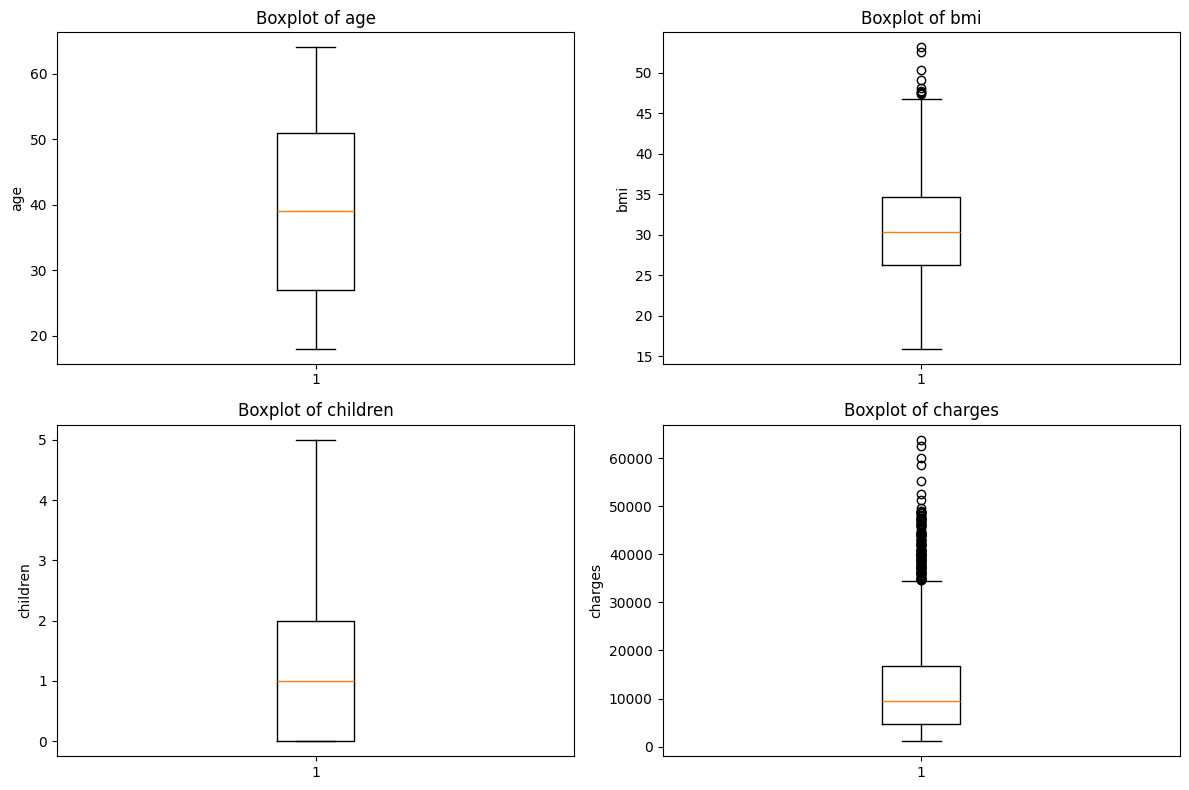

In [19]:
# Outlier Analysis using Boxplots

numerical_columns = ['age', 'bmi', 'children', 'charges']
plt.figure(figsize=(12, 8))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2, 2, i)
    plt.boxplot(df[column])
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)
plt.tight_layout()
plt.show()

In [20]:
# Calculate outliers using the IQR method
for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column}: {len(outliers)} outliers")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print()

age: 0 outliers
Lower bound: -9.00
Upper bound: 87.00

bmi: 9 outliers
Lower bound: 13.67
Upper bound: 47.32

children: 0 outliers
Lower bound: -3.00
Upper bound: 5.00

charges: 139 outliers
Lower bound: -13120.72
Upper bound: 34524.78



**STEP 5 — Basic Statistical Analysis**

Descriptive statistics are used to understand the distribution of the numerical variables and investigate insurance charge differences across smoking status and regions.

In [21]:
# Statistical summary of numerical variables
df[['age', 'bmi', 'children', 'charges']].describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [22]:
# Average insurance charges by smoking status
df.groupby('smoker')['charges'].agg(['count', 'mean', 'median', 'min', 'max'])

,count,mean,median,min,max
smoker,,,,,
no,1063,8440.660307,7345.72660,1121.8739,36910.60803
yes,274,32050.231832,34456.34845,12829.4551,63770.42801


In [23]:
# Average charges by region
df.groupby('region')['charges'].mean().sort_values(ascending=False)

,charges
region,
southeast,14735.411438
northeast,13406.384516
northwest,12450.840844
southwest,12346.937377


**STEP 6 — Start EDA**

####Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand relationships between customer characteristics and insurance charges.

The analysis includes:

- Smoker vs Non-Smoker charges
- Age vs Insurance Charges
- BMI vs Insurance Charges
- Average Charges by Region
- Average Charges by Number of Children
- Correlation Analysis

6.1 Smoker vs Non-smoker

<Figure size 800x600 with 0 Axes>

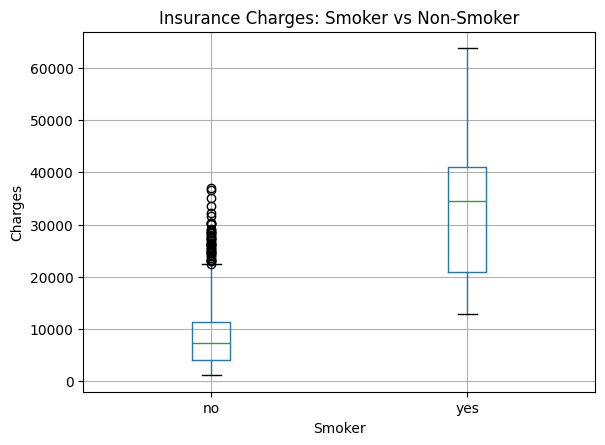

In [24]:
plt.figure(figsize=(8, 6))
df.boxplot(column='charges', by='smoker')
plt.title('Insurance Charges: Smoker vs Non-Smoker')
plt.suptitle('')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

6.2 Age vs Charges

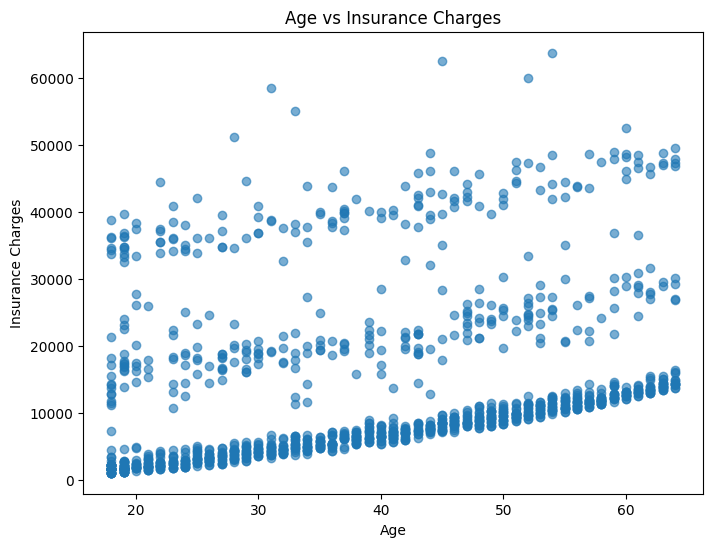

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(df['age'], df['charges'], alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Insurance Charges')
plt.title('Age vs Insurance Charges')
plt.show()

6.3 BMI vs Charges

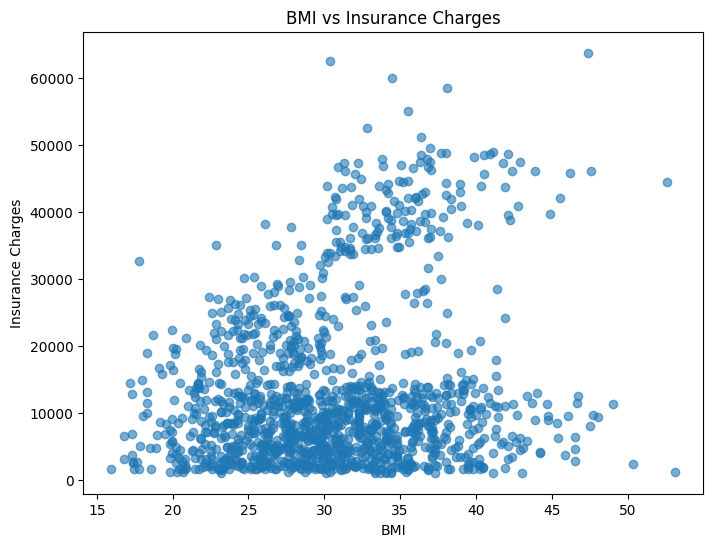

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(df['bmi'], df['charges'], alpha=0.6)
plt.xlabel('BMI')
plt.ylabel('Insurance Charges')
plt.title('BMI vs Insurance Charges')
plt.show()

6.4 Charges by Region

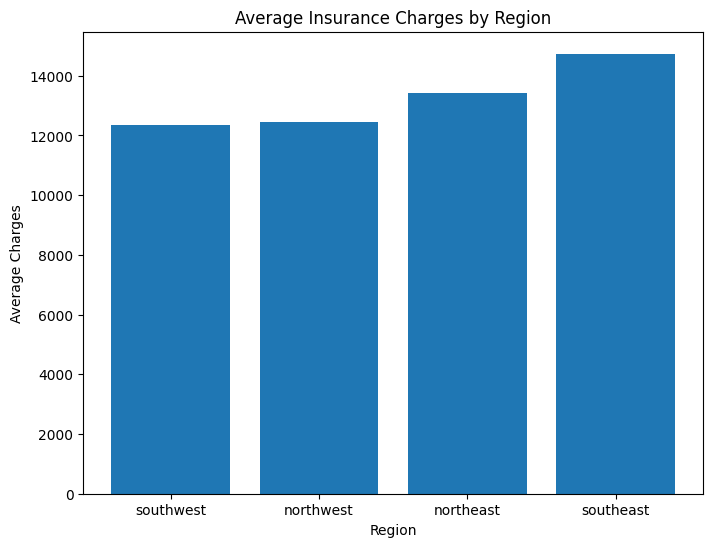

In [27]:
region_charges = df.groupby('region')['charges'].mean().sort_values()
plt.figure(figsize=(8, 6))
plt.bar(region_charges.index, region_charges.values)
plt.xlabel('Region')
plt.ylabel('Average Charges')
plt.title('Average Insurance Charges by Region')
plt.show()

6.5 Children vs Charges

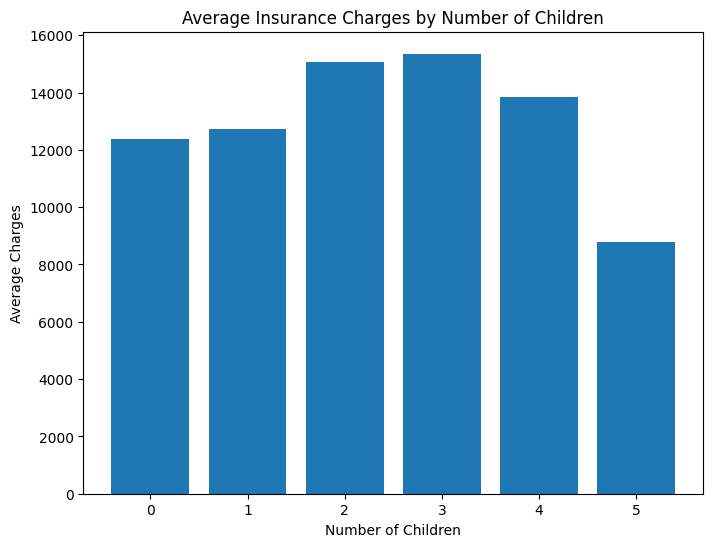

In [28]:
children_charges = df.groupby('children')['charges'].mean()
plt.figure(figsize=(8, 6))
plt.bar(children_charges.index.astype(str), children_charges.values)
plt.xlabel('Number of Children')
plt.ylabel('Average Charges')
plt.title('Average Insurance Charges by Number of Children')
plt.show()

6.6 Correlation Heatmap

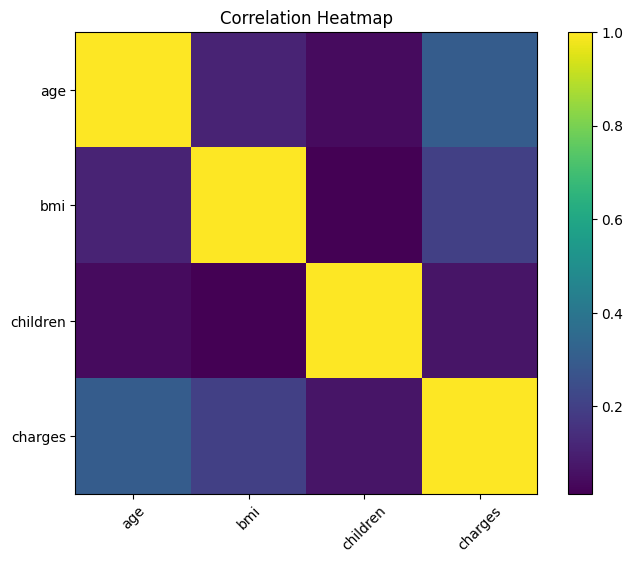

In [29]:
correlation = df[['age', 'bmi', 'children', 'charges']].corr()
plt.figure(figsize=(8, 6))
plt.imshow(correlation, interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title('Correlation Heatmap')
plt.show()

**STEP 7 — Feature Engineering**

A new categorical feature, `bmi_category`, is created from the BMI value.

The BMI values are grouped into four categories:

- Underweight
- Normal
- Overweight
- Obese

This additional feature provides a categorical representation of BMI for the machine learning models.

In [30]:
#Creating BMI Category

def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_category'] = df['bmi'].apply(bmi_category)
df[['bmi', 'bmi_category']].head(10)

,bmi,bmi_category
0,27.900,Overweight
1,33.770,Obese
2,33.000,Obese
3,22.705,Normal
4,28.880,Overweight
5,25.740,Overweight
6,33.440,Obese
7,27.740,Overweight
8,29.830,Overweight
9,25.840,Overweight


In [31]:
# Checking BMI Category distribution
print(df['bmi_category'].value_counts())

bmi_category
Obese          706
Overweight     386
Normal         225
Underweight     20
Name: count, dtype: int64


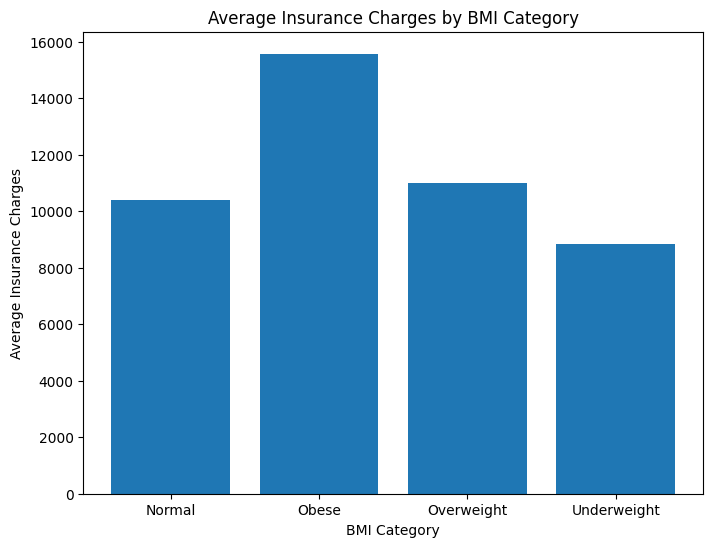

In [32]:
# BMI Category vs Average Insurance Charges
bmi_charges = df.groupby('bmi_category')['charges'].mean()
plt.figure(figsize=(8, 6))
plt.bar(bmi_charges.index, bmi_charges.values)
plt.xlabel('BMI Category')
plt.ylabel('Average Insurance Charges')
plt.title('Average Insurance Charges by BMI Category')
plt.show()

**STEP 8 — Define Features and Target**

The target variable is `charges`, which represents the annual medical insurance cost.

All remaining variables are used as input features for prediction.

In [33]:
X = df.drop('charges', axis=1)
y = df['charges']
print("Features:")
print(X.columns.tolist())
print("\nTarget:")
print(y.name)

Features:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'bmi_category']

Target:
charges


**STEP 9 — Identify Numerical and Categorical Features**

Numerical and categorical variables are identified separately so that appropriate preprocessing can be applied before model training.

In [34]:
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
print("Numerical Features:")
print(numerical_features)
print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'bmi', 'children']

Categorical Features:
['sex', 'smoker', 'region', 'bmi_category']


**STEP 10 — Train-Test Split**

The dataset is divided into training and testing sets using an 80:20 ratio.

The training set is used to train the models, while the testing set is used to evaluate their performance on unseen data.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1069, 7)
Testing data: (268, 7)


**STEP 11 — Preprocessing**

Categorical variables are converted into numerical representations using One-Hot Encoding.

A ColumnTransformer is used to apply the appropriate preprocessing to numerical and categorical features.

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


**STEP 12 — Model 1: Multiple Linear Regression**

Multiple Linear Regression is used as the baseline regression model for predicting insurance charges.

In [37]:
# Model 1: Multiple Linear Regression
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions
y_pred_linear = linear_model.predict(X_test)

print("Multiple Linear Regression trained successfully!")

Multiple Linear Regression trained successfully!


In [38]:
# Evaluating Linear Regression

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Multiple Linear Regression Results")
print("-----------------------------------")
print(f"MAE  : {mae_linear:.2f}")
print(f"RMSE : {rmse_linear:.2f}")
print(f"R²   : {r2_linear:.4f}")

Multiple Linear Regression Results
-----------------------------------
MAE  : 4334.48
RMSE : 6023.86
R²   : 0.8025


### Result

The Multiple Linear Regression model achieved an R² score of 0.8025, with an MAE of $4,334.48 and  RMSE of  $6,023.86.

**STEP 13 — Model 2: Polynomial Regression**

Polynomial Regression with degree 2 is used to capture possible non-linear relationships between the numerical features and insurance charges.

In [39]:
polynomial_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            PolynomialFeatures(degree=2, include_bias=False),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

print("Polynomial preprocessing pipeline created!")

Polynomial preprocessing pipeline created!


In [40]:
# Model 2: Polynomial Regression (Degree 2)
polynomial_model = Pipeline(steps=[
    ('preprocessor', polynomial_preprocessor),
    ('regressor', LinearRegression())
])

# Train the model
polynomial_model.fit(X_train, y_train)

# Make predictions
y_pred_poly = polynomial_model.predict(X_test)

print("Polynomial Regression trained successfully!")

Polynomial Regression trained successfully!


In [41]:
# Evaluating Polynomial Regression
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression Results")
print("-----------------------------")
print(f"MAE  : {mae_poly:.2f}")
print(f"RMSE : {rmse_poly:.2f}")
print(f"R²   : {r2_poly:.4f}")

Polynomial Regression Results
-----------------------------
MAE  : 4389.74
RMSE : 6120.79
R²   : 0.7961


### Result

The Polynomial Regression model achieved an R² score of 0.7961, with an MAE of $4,389.74 and RMSE of $6,120.79.

**STEP 14 — Model 3: Decision Tree Regressor**

The Decision Tree Regressor is used to model non-linear relationships and decision-based patterns in insurance charge prediction.

In [42]:
# Model 3: Decision Tree Regressor
decision_tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

# Train the model
decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred_tree = decision_tree_model.predict(X_test)

print("Decision Tree Regressor trained successfully!")

Decision Tree Regressor trained successfully!


In [43]:
# Evaluating Decision Tree
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)
print("Decision Tree Regressor Results")
print("--------------------------------")
print(f"MAE  : {mae_tree:.2f}")
print(f"RMSE : {rmse_tree:.2f}")
print(f"R²   : {r2_tree:.4f}")

Decision Tree Regressor Results
--------------------------------
MAE  : 2955.06
RMSE : 6372.11
R²   : 0.7790


### Result

The Decision Tree Regressor achieved an R² score of 0.7790, with an MAE of $2,955.06 and RMSE of $6,372.11.

**STEP 15 — Model 4: Random Forest Regressor**

The Random Forest Regressor combines multiple decision trees to improve prediction performance and capture complex relationships between the input features and insurance charges.

In [44]:
# Model 4: Random Forest Regressor
random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest Regressor trained successfully!")

Random Forest Regressor trained successfully!


In [45]:
# Evaluating Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest Regressor Results")
print("--------------------------------")
print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Regressor Results
--------------------------------
MAE  : 2574.23
RMSE : 4641.42
R²   : 0.8828


### Result

The Random Forest Regressor achieved an R² score of 0.8828, with an MAE of $2,574.23 and RMSE of $4,641.42.

**STEP 16 — Compare All 4 Models**

The four regression models are compared using MAE, RMSE, and R² score.

For MAE and RMSE, lower values indicate better performance. For R², a higher value indicates better predictive performance.

In [46]:
# Compare all four models

results = pd.DataFrame({
    'Model': [
        'Multiple Linear Regression',
        'Polynomial Regression (Degree 2)',
        'Decision Tree Regressor',
        'Random Forest Regressor'
    ],
    'MAE': [
        mae_linear,
        mae_poly,
        mae_tree,
        mae_rf
    ],
    'RMSE': [
        rmse_linear,
        rmse_poly,
        rmse_tree,
        rmse_rf
    ],
    'R2': [
        r2_linear,
        r2_poly,
        r2_tree,
        r2_rf
    ]
})

results = results.sort_values(by='R2', ascending=False)

results

,Model,MAE,RMSE,R2
3,Random Forest Regressor,2574.233940,4641.421716,0.882764
0,Multiple Linear Regression,4334.481445,6023.856240,0.802527
1,Polynomial Regression (Degree 2),4389.741972,6120.785299,0.796121
2,Decision Tree Regressor,2955.060627,6372.112320,0.779034


### Model Comparison Interpretation

The Random Forest Regressor achieved the best overall performance among the four models.

It obtained the lowest MAE of $2,574.23 and the lowest RMSE of $4,641.42, while also achieving the highest R² score of 0.8828.

Therefore, Random Forest Regressor is selected as the best-performing model for predicting insurance charges.

**STEP 17 — Predicted vs Actual Plot**

The predicted vs actual plot is used to visually evaluate the performance of the Random Forest Regressor.

Points closer to the diagonal reference line represent more accurate predictions.

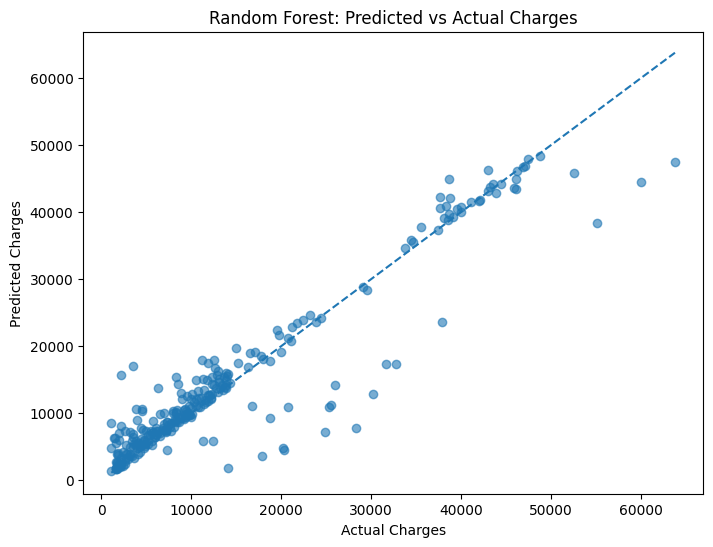

In [47]:
# Predicted vs Actual Charges - Best Model

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.6)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Random Forest: Predicted vs Actual Charges')
plt.show()

**STEP 18 — Feature Importance**

Feature importance from the Random Forest Regressor is analyzed to identify the features that contribute most to insurance charge prediction.

In [48]:
# Extracting feature names after preprocessing

rf_preprocessor = random_forest_model.named_steps['preprocessor']
rf_regressor = random_forest_model.named_steps['regressor']

feature_names = rf_preprocessor.get_feature_names_out()

importances = rf_regressor.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_df

,Feature,Importance
5,cat__smoker_no,0.449889
1,num__bmi,0.180997
6,cat__smoker_yes,0.150888
0,num__age,0.135994
12,cat__bmi_category_Obese,0.026186
2,num__children,0.022245
8,cat__region_northwest,0.006039
7,cat__region_northeast,0.004977
9,cat__region_southeast,0.004890
4,cat__sex_male,0.004241


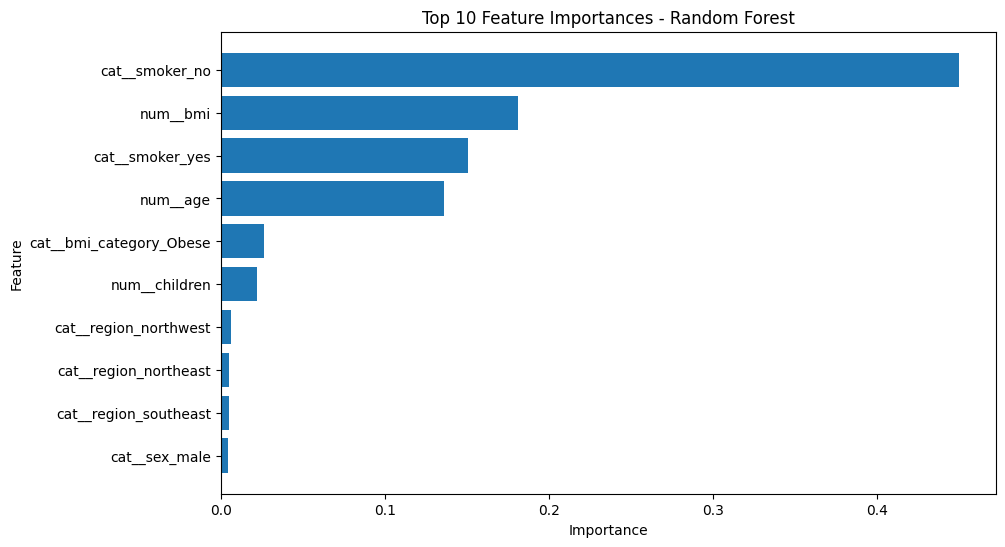

In [49]:
# Creating the Feature Importance Chart

top_features = feature_importance_df.head(10)
plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances - Random Forest')
plt.show()

### Feature Importance Interpretation

The feature importance analysis shows that smoking status is the most influential factor in the Random Forest model.

The `smoker_no` feature has the highest importance score of 0.449889, followed by BMI with 0.180997, `smoker_yes` with 0.150888, and age with 0.135994.

These results indicate that smoking status, BMI, and age are among the most influential features used by the model to predict insurance charges.

**STEP 19 — Save the Comparison Table**

The model comparison results and feature importance values are saved as CSV files for further analysis and project documentation.

In [50]:
# Saving the  model comparison results

results.to_csv('model_comparison.csv', index=False)
print("Model comparison saved successfully!")

Model comparison saved successfully!


In [51]:
# Saving the feature importance results

feature_importance_df.to_csv(
    'feature_importance.csv',
    index=False
)
print("Feature importance saved successfully!")

Feature importance saved successfully!


In [52]:
# Display feature importance

feature_importance_df.head(10)

,Feature,Importance
5,cat__smoker_no,0.449889
1,num__bmi,0.180997
6,cat__smoker_yes,0.150888
0,num__age,0.135994
12,cat__bmi_category_Obese,0.026186
2,num__children,0.022245
8,cat__region_northwest,0.006039
7,cat__region_northeast,0.004977
9,cat__region_southeast,0.004890
4,cat__sex_male,0.004241


In [53]:
# Display the most important feature

print("Most important feature:")
print(feature_importance_df.iloc[0])

Most important feature:
Feature       cat__smoker_no
Importance          0.449889
Name: 5, dtype: object


## Feature Importance Analysis

The Random Forest Regressor feature importance analysis shows that smoking status is the most influential feature in predicting insurance charges. The `smoker_no` feature has the highest importance score of 0.449889.

BMI is the second most important feature with an importance score of 0.180997, followed by `smoker_yes` with 0.150888 and age with 0.135994.

These results indicate that smoking status, BMI, and age are the major factors contributing to the prediction of insurance premium costs in this dataset.

In [54]:
# Clean feature names for visualization

clean_feature_names = []

for feature in feature_importance_df['Feature']:
    feature = feature.replace('num__', '')
    feature = feature.replace('cat__', '')
    feature = feature.replace('_', ' ')
    clean_feature_names.append(feature.title())

feature_importance_clean = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance': feature_importance_df['Importance']
})

feature_importance_clean.head(10)

,Feature,Importance
5,Smoker No,0.449889
1,Bmi,0.180997
6,Smoker Yes,0.150888
0,Age,0.135994
12,Bmi Category Obese,0.026186
2,Children,0.022245
8,Region Northwest,0.006039
7,Region Northeast,0.004977
9,Region Southeast,0.004890
4,Sex Male,0.004241


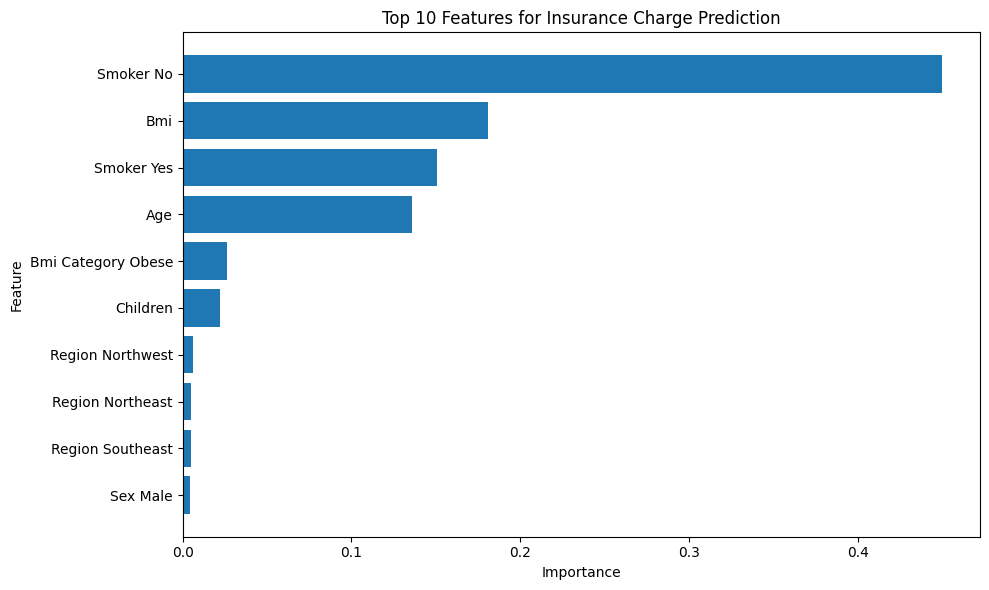

In [55]:
# Final Feature Importance Visualization

top_features = feature_importance_clean.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Features for Insurance Charge Prediction')

plt.tight_layout()
plt.show()

In [56]:
feature_importance_clean.to_csv(
    'feature_importance.csv',
    index=False
)

print("Feature importance file saved successfully!")

Feature importance file saved successfully!


**STEP 20 — Final Model Recommendation**

The best-performing model is identified based on the evaluation metrics obtained from the test dataset.

In [57]:
# Identifying  the best model based on R²
best_model = results.iloc[0]
print("Best Model:", best_model['Model'])
print("R²:", round(best_model['R2'], 4))
print("MAE:", round(best_model['MAE'], 2))
print("RMSE:", round(best_model['RMSE'], 2))

Best Model: Random Forest Regressor
R²: 0.8828
MAE: 2574.23
RMSE: 4641.42


### **Final Recommendation**

The **Random Forest Regressor** is selected as the final model for insurance premium cost prediction.

It achieved an R² score of 0.8828, MAE of 2,574.23, and RMSE of 4,641.42. Among the four models evaluated, it achieved the highest R² and the lowest MAE and RMSE.

Therefore, the Random Forest Regressor provides the best overall predictive performance for this dataset.

In [58]:
import joblib
joblib.dump(linear_model, 'linear_regression.pkl')
joblib.dump(polynomial_model, 'polynomial_regression.pkl')
joblib.dump(decision_tree_model, 'decision_tree.pkl')
joblib.dump(random_forest_model, 'random_forest.pkl')
print("All four Insurance models saved successfully!")

All four Insurance models saved successfully!


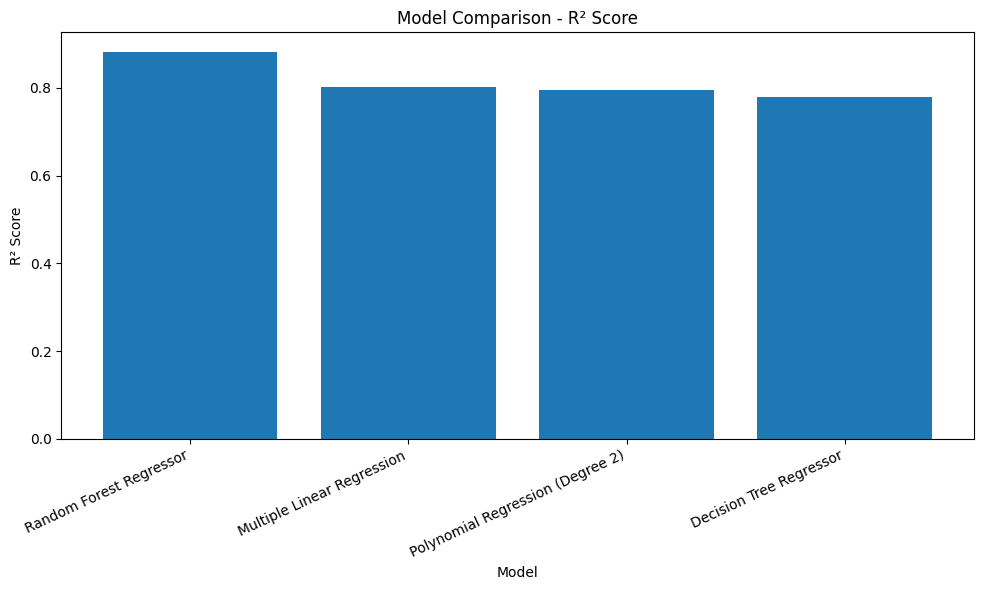

Comparison chart saved successfully!


In [59]:
# Create and save Model Comparison Chart

plt.figure(figsize=(10, 6))
plt.bar(
    results['Model'],
    results['R2']
)
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('Model Comparison - R² Score')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('comparison_table.png', dpi=300, bbox_inches='tight')
plt.show()
print("Comparison chart saved successfully!")

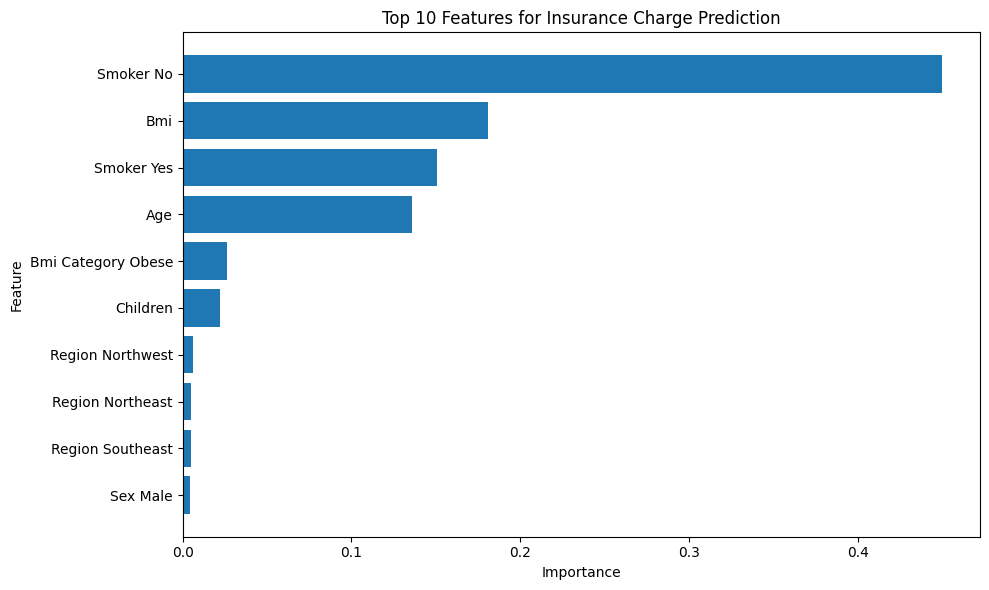

Feature importance chart saved successfully!


In [60]:
# Create and save Feature Importance Chart

top_features = feature_importance_clean.head(10)
plt.figure(figsize=(10, 6))
plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Features for Insurance Charge Prediction')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Feature importance chart saved successfully!")

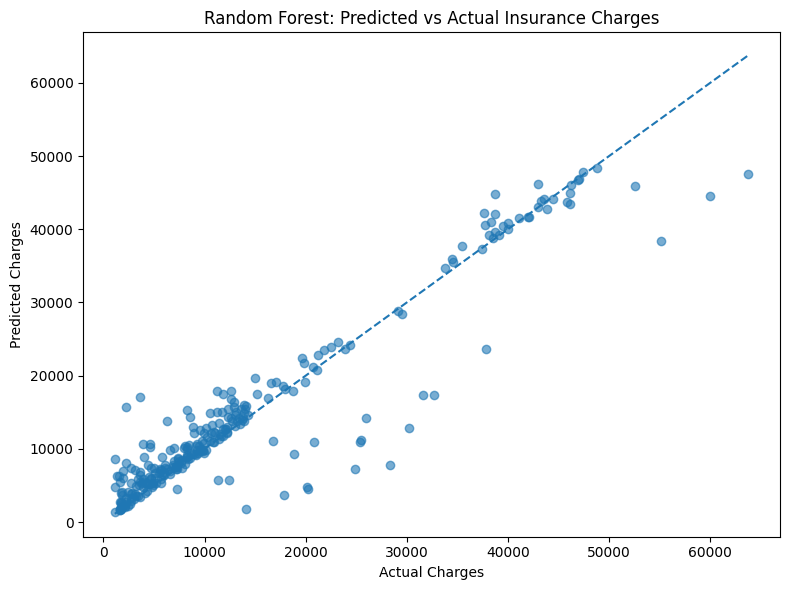

Prediction plot saved successfully!


In [61]:
# Create and save Prediction Plot

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Random Forest: Predicted vs Actual Insurance Charges')
plt.tight_layout()
plt.savefig('prediction_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Prediction plot saved successfully!")

# **Conclusion**

- This project developed a machine learning approach for predicting annual medical insurance charges.

- The dataset was cleaned, validated, explored, and enhanced through feature engineering. Four regression models were trained and evaluated using MAE, RMSE, and R² score.

- Among the models tested, the Random Forest Regressor achieved the best performance with an R² score of 0.8828, MAE of $2,574.23, and RMSE of $4,641.42.

- Feature importance analysis showed that smoking status, BMI, and age were among the most influential features for insurance charge prediction.

- Based on the evaluation results, the Random Forest Regressor is recommended as the final model for this insurance pricing prediction task.